## Basic ChatBot with LangGraph

In [1]:
from typing import Annotated
import langchain
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END



In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]



In [3]:
print(State)

<class '__main__.State'>


In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
## llm
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant")

##llm.invoke('hi')

In [6]:
## for every node we need to create a definition 

## node which has state + llm
def ChatBot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}


In [7]:
## intialize graph
graph_builder = StateGraph(State)

## add node to the graph
graph_builder.add_node("llmchatbot", ChatBot)

## add edges to the graph
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph
graph = graph_builder.compile()

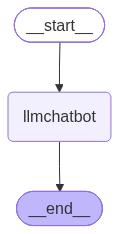

In [8]:

## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [9]:
from langchain_core.messages import HumanMessage
response = graph.invoke({"messages": "hi"})

response["messages"][-1].content


'How can I assist you today?'

In [10]:
for event in graph.stream({"messages": "Hi"}):
    for value in event.values():
        print(value["messages"][-1].content)

How can I assist you today?


## chatbot with tool

In [11]:
from langchain_tavily import TavilySearch

## tool 1
search_tool = TavilySearch(max_result=2)
search_tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': '/goto?url=CAESYgHuR6pN-i_op8u4K-SaWuZ0WIQm_9X-8T9WtsE78l-eEdQuyPGVsNkgyB-Lf0kb825gbWBsMPusPs0_x9mP26UxwVEj3UlwvLqhz1dFb8vCySAxQM7F9nT4BKjIfkVdOeip',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows.Read more',
   'score': 0.93468803,
   'raw_content': None},
  {'url': '/goto?url=CAESWwHuR6pNKY6WqHHEMODteBncG7njiI9X-2Bx3ntPTAy88_adEfdRmWqN59zaRjC8dB0XaHdAa8TFzLjZh7LnzXOKBDiGo4VY1gIDrVqxeIUK6B_S9-nCp8TD8ts%3D',
   'title': 'LangGraph: Agent Orchestration Framework for Reliable AI ...',
   'content': 'LangGraph, an agent runtime and low-level orchestration framework. LangGraph sets the foundation for how we can build and scale AI workloads',
   'score': 0.8800674,
   'raw_content': None},
  {'url': 'https://www.geeksforgeeks.org/mach

In [12]:
## Custom function
from langchain_core.tools import tool
## tool 2
@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers."""
    return a * b

In [13]:
tools = [search_tool, multiply]

llm_with_tools = llm.bind_tools(tools)

In [14]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001E88FA92ED0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E88FB57650>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engin

In [15]:
## stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## state
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}



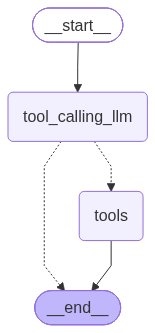

In [16]:
## Graph

builder = StateGraph(State)

# add node 1 
builder.add_node("tool_calling_llm", tool_calling_llm)

# add node 2
builder.add_node("tools", ToolNode(tools))

# add edges

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", END)


## compile
graph = builder.compile()

# display

display(Image(graph.get_graph().draw_mermaid_png()))



In [17]:
response = graph.invoke({"messages": "what is the recent kashmir news?"})

In [18]:
response["messages"][-1].content

'{"query": "Kashmir recent news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://socialistworker.co.uk/international/why-are-kashmiris-rising-up-against-pakistani-state", "title": "Why are Kashmiris rising up against Pakistani state?", "content": "### India and Pakistan on brink of war over Kashmir\\n\\n25 April 2025\\n\\nMore News\\n\\n## Latest News\\n\\n[](   International\\n\\n### Kenyan president cites ‘benefits’ of British army base despite abuse scandals\\n\\nPutting imperialist interests before justice\\n\\n29 July 2026\\n\\nTens of thousands of people celebrated as minister resigned   International\\n\\n### India’s \'Cockroach\' movement declares victory\\n\\nMass protests forced the education minister to resign\\n\\n27 July 2026 [...] Topics Kashmir, Pakistan\\n\\n## Related News\\n\\nThousands marched in London in solidarity (Photo: JklfUk/X)   International\\n\\n### Crackdown in Kashmir sees Pakistani state kills pro-democracy activi

In [19]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent kashmir news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (36vy65vps)
 Call ID: 36vy65vps
  Args:
    query: Kashmir recent news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Kashmir recent news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://socialistworker.co.uk/international/why-are-kashmiris-rising-up-against-pakistani-state", "title": "Why are Kashmiris rising up against Pakistani state?", "content": "### India and Pakistan on brink of war over Kashmir\n\n25 April 2025\n\nMore News\n\n## Latest News\n\n[](   International\n\n### Kenyan president cites ‘benefits’ of British army base despite abuse scandals\n\nPutting imperialist interests before justice\n\n29 July 2026\n\nTens

In [20]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (ym82nxsd6)
 Call ID: ym82nxsd6
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [21]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (xx4zkvnb3)
 Call ID: xx4zkvnb3
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: month
    topic: news
  multiply (xrntx1cpa)
 Call ID: xrntx1cpa
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-june-2026", "title": "The latest AI news we announced in June 2026", "content": "Explore how AI could help modernize public services. A new Gemini-powered planning prototype for councils, developed in collaboration with Google DeepMind, Faculty and the UK government, demonst

## ReAct Agent Architecture

In [22]:
## stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [23]:
## state
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

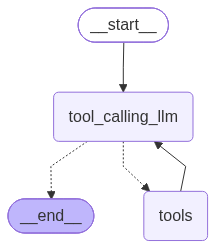

In [24]:
## Graph

builder = StateGraph(State)

# add node 1 
builder.add_node("tool_calling_llm", tool_calling_llm)

# add node 2
builder.add_node("tools", ToolNode(tools))

# add edges

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")


## compile
graph = builder.compile()

# display

display(Image(graph.get_graph().draw_mermaid_png()))



In [25]:
response = graph.invoke({"messages": "what is the recent kashmir news?"})

In [26]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (ec6tcj1jf)
 Call ID: ec6tcj1jf
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: day
    topic: news
  multiply (m827v1a5g)
 Call ID: m827v1a5g
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.fintechfutures.com/ai-in-fintech/july-2026-top-five-ai-stories-of-the-month", "title": "July 2026: Top five AI stories of the month", "content": "## CaixaBank completes first agentic payment with Visa\n\nCaixaBank in Spain has successfully completed a real-world payment initiated by an AI agent acting on behalf of a human cardholder.

## Adding Memory In Agentic Graph

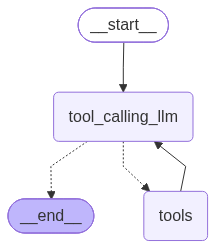

In [27]:
## stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# node definition
def tool_calling_llm(state:State):
    return {"message":[llm_with_tools.invoke(state["messages"])]}

# Graph
builder = StateGraph(State)

## add node
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## add edge
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

## compile
graph = builder.compile(checkpointer=memory)
# display

display(Image(graph.get_graph().draw_mermaid_png()))

## 

In [28]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph.invoke({'messages':"Hi,My name is Humaima And I like reading"
""},config)

{'messages': [HumanMessage(content='Hi,My name is Humaima And I like reading', additional_kwargs={}, response_metadata={}, id='38c06db4-ec9a-4b5c-a497-07f4e018190b')]}

In [29]:
response['messages'][-1].content


'The final answer is 50.'

In [30]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Hey what is my name


In [31]:
response=graph.invoke({"messages":"Hey do you remember my name"},config=config)

print(response['messages'][-1].content)

Hey do you remember my name


## Streaming


In [32]:

from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [33]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

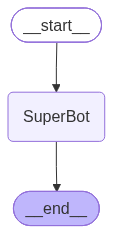

In [34]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [35]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='c05a542f-a31f-4369-b3b0-e06e3f5c0b6b'),
  AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, and it's great that you enjoy it. Which aspect of cricket do you like the most - the fast-paced action, the strategic gameplay, or the excitement of watching a live match?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 45, 'total_tokens': 96, 'completion_time': 0.072881684, 'completion_tokens_details': None, 'prompt_time': 0.002670625, 'prompt_tokens_details': None, 'queue_time': 0.005447058, 'total_time': 0.075552309}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fb36c-0fb1-7631-8001-9d81e1317618-0', tool_calls=[], invalid_tool_calls=[], usage_metadata

## Streaming
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

- values : This streams the full state of the graph after each node is called.
- updates : This streams updates to the state of the graph after each node is called.

In [36]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Krish! Cricket is a fantastic sport, and I'm happy to chat with you about it. Are you a fan of any particular team or player? Do you enjoy playing cricket yourself or is it more of a spectator interest?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 45, 'total_tokens': 96, 'completion_time': 0.07843276, 'completion_tokens_details': None, 'prompt_time': 0.003582093, 'prompt_tokens_details': None, 'queue_time': 0.006213578, 'total_time': 0.082014853}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fb36c-1080-7d03-bb93-c5740a95ac70-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 51, 'total_tokens': 96})]}}


In [37]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='ba06c0e5-d34b-488e-b92d-9d13846a80a2'), AIMessage(content="Nice to meet you, Krish! Cricket is a fantastic sport, and I'm happy to chat with you about it. Are you a fan of any particular team or player? Do you enjoy playing cricket yourself or is it more of a spectator interest?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 45, 'total_tokens': 96, 'completion_time': 0.07843276, 'completion_tokens_details': None, 'prompt_time': 0.003582093, 'prompt_tokens_details': None, 'queue_time': 0.006213578, 'total_time': 0.082014853}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fb36c-1080-7d03-bb93-c5740a95ac70-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_

In [38]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, and I'm happy to chat with you about it. Are you a fan of a particular team or player? Do you have a favorite format of the game, such as Test matches, One-Day Internationals (ODIs), or Twenty20 (T20) cricket?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 45, 'total_tokens': 114, 'completion_time': 0.082142463, 'completion_tokens_details': None, 'prompt_time': 0.00227035, 'prompt_tokens_details': None, 'queue_time': 0.005389129, 'total_time': 0.084412813}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fb36c-1787-7170-9f99-c39acd50bfb2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 69, 'total_tokens': 114})]}}


In [39]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='8529c5c4-9c42-42a8-923f-769e63581ed7'), AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, and I'm happy to chat with you about it. Are you a fan of a particular team or player? Do you have a favorite format of the game, such as Test matches, One-Day Internationals (ODIs), or Twenty20 (T20) cricket?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 45, 'total_tokens': 114, 'completion_time': 0.082142463, 'completion_tokens_details': None, 'prompt_time': 0.00227035, 'prompt_tokens_details': None, 'queue_time': 0.005389129, 'total_time': 0.084412813}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fb36c-1787-7170-9f99-c39acd50bfb2-0', tool_calls=[], i

In [40]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019fb36c-273a-76a1-982a-1e6bb02e5496', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='3bcf1f22-2923-4e16-a6cf-397e85e99f45')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019fb36c-2742-7b63-bf18-bd6d60797865', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:87a183ba-91a6-50ce-5cf1-3ce1b0324e18'}, 'parent_ids': ['019fb36c-273a-76a1-982a-1e6bb02e5496']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':